In [85]:
# Import packages
%load_ext autoreload
%autoreload 2
    
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table, hstack
from astropy.io import fits
from astropy.wcs import WCS
import astropy.units as u

from astropy.stats import sigma_clipped_stats
from astropy.modeling.fitting import LevMarLSQFitter
from photutils.psf import EPSFModel, ImagePSF
from photutils.detection import DAOStarFinder
from photutils.datasets import make_model_image
from photutils.psf import PSFPhotometry, SourceGrouper

# For parallelization
from joblib import Parallel, delayed

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [86]:
from ast_simulation import run_ast_parallel, one_star_trial

In [ ]:
# =============================================================================
# Main setup and execution
# =============================================================================

# Define bands and Zero Points
bands = ['F106', 'F158']
zp = -2.5 * np.log10(1 * ((0.11 * u.arcsec)**2).to(u.steradian).value * 1e6 / 3631)
ZPs = {'F106': zp, 'F158': zp} # Approx Roman ZPs

# PSF setup
import romanisim
import romanisim.parameters
from romanisim.l3 import l3_psf
scale = romanisim.parameters.pixel_scale
nx_psf = ny_psf = (int(5 / scale) // 2) * 2 + 1

epsfs = {}
psf_imgs = {}

# Generate PSFs for both bands
for band in bands:
    # Use appropriate wavelength for PSF generation if available, else approximate
    # romanisim might handle string band names
    roman_psf = l3_psf(band, 1, stpsf=True, fov_arcsec=5) # scale might need adjustment per band wavelength if critical
    img_psf_model = roman_psf.drawImage(nx=nx_psf, ny=ny_psf, scale=scale, method="auto")
    psf_data = img_psf_model.array / img_psf_model.array.sum()
    
    psf_imgs[band] = psf_data
    epsfs[band] = ImagePSF(psf_data, oversampling=1)


In [120]:
# Load Background Images
bkg_imgs = {}
import sep
for band in bands:
    fname = f'/scratch/gpfs/JENNYG/jiaxuanl/Data/SBF/Rosesim/sky_jaguar_test/{band}_642s.fits'
    hdu = fits.open(fname)
    # w = WCS(hdu[0].header) # Not stricly used for injection unless RA/Dec needed
    bkg_data = hdu[0].data.astype(float)
    
    # Subtract background
    bkg_model = sep.Background(bkg_data, bh=128, bw=128)
    bkg_data -= bkg_model.globalback
    bkg_imgs[band] = bkg_data
    print(f"Loaded {band} image from {fname}")
    

Loaded F106 image from /scratch/gpfs/JENNYG/jiaxuanl/Data/SBF/Rosesim/sky_jaguar_test/F106_642s.fits
Loaded F158 image from /scratch/gpfs/JENNYG/jiaxuanl/Data/SBF/Rosesim/sky_jaguar_test/F158_642s.fits


Loaded F106 image from /scratch/gpfs/JENNYG/jiaxuanl/Data/SBF/Rosesim/sky_jaguar_test/F106_642s.fits
Loaded F158 image from /scratch/gpfs/JENNYG/jiaxuanl/Data/SBF/Rosesim/sky_jaguar_test/F158_642s.fits


In [189]:
fluxes = {'F158': 10**(-0.4 * (25 - zp)), 'F106': 10**(-0.4 * (25 - zp))}
stars_out = one_star_trial(bkg_imgs, epsfs, x0=149, y0=300, fluxes=fluxes, fwhm=1.2, rmatch=2.0, aperture_radius=1.5, bands=['F158'])
print('Aper SNR', (stars_out['ap_flux'] / stars_out['ap_flux_err'])[0])
print('PSF SNR', (stars_out['flux_fit'] / stars_out['flux_err'])[0])

Aper SNR 9.382748958541683
PSF SNR 15.618763969475992


In [185]:
fluxes = {'F158': 10**(-0.4 * (25 - zp)), 'F106': 10**(-0.4 * (25 - zp))}
stars_out = one_star_trial(bkg_imgs, epsfs, x0=149, y0=300, fluxes=fluxes, fwhm=1.2, rmatch=2.0, aperture_radius=1.5, bands=['F158'])
print('Aper SNR', (stars_out['ap_flux'] / stars_out['ap_flux_err'])[0])
print('PSF SNR', (stars_out['flux_fit'] / stars_out['flux_err'])[0])

Aper SNR 9.387802129209788
PSF SNR 15.658046557351


In [186]:
fluxes = {'F158': 10**(-0.4 * (25 - zp)), 'F106': 10**(-0.4 * (25 - zp))}
stars_out = one_star_trial(bkg_imgs, epsfs, x0=149, y0=300, fluxes=fluxes, fwhm=1.2, rmatch=2.0, aperture_radius=1.5, bands=['F106'])
print('Aper SNR', (stars_out['ap_flux'] / stars_out['ap_flux_err'])[0])
print('PSF SNR', (stars_out['flux_fit'] / stars_out['flux_err'])[0])

Aper SNR 13.98101534636043
PSF SNR 24.766889369731157


In [163]:
np.std(bkg_imgs['F106']), np.std(bkg_imgs['F158'])

(np.float64(0.02387235630388317), np.float64(0.02365173637832728))

In [164]:
fluxes

{'F158': np.float64(1.2767067218622214),
 'F106': np.float64(1.2767067218622214)}

15.658046557351


5.440141856773865


In [26]:
# Run AST in ast_simulation.py

## Completeness

In [42]:
def logistic_completeness(m, m50, w):
    return 1.0 / (1.0 + np.exp((m - m50) / w))

def mag_uncertainty_func(m, slope, intercept):
    return 10**(m * slope + intercept)

from scipy.optimize import curve_fit

def fit_logistic_completeness(mag, comp):
    """
    Fit a logistic completeness function.

    Returns
    -------
    popt : (m50, w)
    pcov : covariance matrix
    """
    mag = np.asarray(mag)
    comp = np.asarray(comp)

    # Use only valid bins
    ok = np.isfinite(mag) & np.isfinite(comp) & (comp > 0) & (comp < 1)
    mag = mag[ok]
    comp = comp[ok]

    # Initial guesses:
    m50_init = np.interp(0.5, comp[::-1], mag[::-1])  # rough 50% estimate
    w_init = 0.3                                      # typical transition width

    popt, pcov = curve_fit(
        logistic_completeness,
        mag, comp,
        p0=[m50_init, w_init],
        bounds=([mag.min(), 0.01], [mag.max(), 5.0]),
    )
    return popt, pcov

from astropy.stats import sigma_clip

def delta_m_scatter_vs_mag(
    mag_in,
    delta_m,
    *,
    mag_bins,
    clip_sigma=3.0,
    clip_iters=3,
    method="mad",
    min_per_bin=10,
):
    """
    Compute sigma-clipped scatter of delta_m as a function of mag_in.

    Parameters
    ----------
    mag_in : array-like
        Input magnitudes.
    delta_m : array-like
        delta_m = mag_in - mag_out (or vice versa; sign does not matter for scatter).
    mag_bins : array-like
        Magnitude bin edges.
    clip_sigma : float
        Sigma threshold for sigma clipping.
    clip_iters : int
        Number of sigma-clipping iterations.
    method : {'mad','rms'}
        Scatter estimator.
    min_per_bin : int
        Minimum number of points required to compute scatter.

    Returns
    -------
    tab : astropy.table.Table
        Columns:
          mag_center, n_used, dmag_med, scatter
    """
    mag_in = np.asarray(mag_in)
    delta_m = np.asarray(delta_m)

    idx = np.digitize(mag_in, mag_bins) - 1

    out = Table()
    out["mag_center"] = 0.5 * (mag_bins[:-1] + mag_bins[1:])
    out["n_used"] = np.zeros(len(out), dtype=int)
    out["dmag_med"] = np.nan
    out["scatter"] = np.nan

    for i in range(len(out)):
        m = (idx == i) & np.isfinite(delta_m)
        if np.sum(m) < min_per_bin:
            continue

        dm = delta_m[m]

        # iterative sigma clipping
        clipped = sigma_clip(
            dm,
            sigma=clip_sigma,
            maxiters=clip_iters,
            cenfunc="median",
            stdfunc="std",
        )

        dm_clipped = dm[~clipped.mask]
        if len(dm_clipped) < min_per_bin:
            continue

        out["n_used"][i] = len(dm_clipped)
        out["dmag_med"][i] = np.median(dm_clipped)

        if method == "mad":
            out["scatter"][i] = (
                1.4826 * np.median(np.abs(dm_clipped - np.median(dm_clipped)))
            )
        elif method == "rms":
            out["scatter"][i] = np.sqrt(np.mean((dm_clipped - np.mean(dm_clipped))**2))
        else:
            raise ValueError("method must be 'mad' or 'rms'")

    return out


In [30]:
from scipy.stats import binned_statistic

In [31]:
tab = Table.read('/scratch/gpfs/JENNYG/jiaxuanl/Data/SBF/Rosesim/sky_jaguar_test/ast_results_10000.fits')

Best fit completeness for F158: 26.265128309473074 0.20950393512684282
Best fit completeness for F106: 26.65420231875137 0.24173024529576023


Text(0, 0.5, 'Completeness')

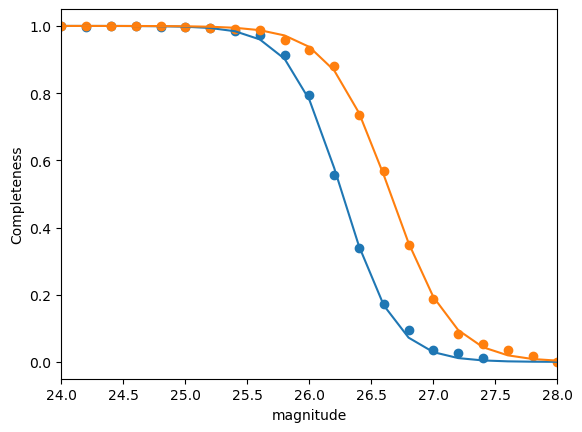

In [35]:
comp_bins = np.arange(17.5, 29.6, 0.2)
res = binned_statistic(tab['mag_in_F158'], tab['recovered_F158'], bins=comp_bins, statistic='mean')
mag, comp = 0.5 * (res.bin_edges[:-1] + res.bin_edges[1:]), res.statistic
print('Best fit completeness for F158:', *fit_logistic_completeness(mag, comp)[0])
plt.plot(mag, logistic_completeness(mag, *fit_logistic_completeness(mag, comp)[0]), label='F158')
plt.scatter(mag, comp)
plt.xlim(24, 28)

res = binned_statistic(tab['mag_in_F106'], tab['recovered_F106'], bins=comp_bins, statistic='mean')
mag, comp = 0.5 * (res.bin_edges[:-1] + res.bin_edges[1:]), res.statistic
print('Best fit completeness for F106:', *fit_logistic_completeness(mag, comp)[0])
plt.plot(mag, logistic_completeness(mag, *fit_logistic_completeness(mag, comp)[0]), label='F106')
plt.scatter(mag, comp)
plt.xlim(24, 28)

plt.xlabel('magnitude')
plt.ylabel('Completeness')

## Photometric uncertainty

In [36]:
delta_m = tab["mag_in_F158"] - tab["mag_out_F158"]
mag_bins = np.arange(23.0, 27, 0.3)

scatter_tab = delta_m_scatter_vs_mag(
    tab["mag_in_F158"],
    delta_m,
    mag_bins=mag_bins,
    clip_sigma=3.0,
    clip_iters=3,
    method="mad",        # strongly recommended
    min_per_bin=20,
)
# Fit for a relation between sigma_mag and mag
flag = (scatter_tab['mag_center'] <= 26.0) & ~np.isnan(scatter_tab['scatter'])
print('Best fit in F158 :', np.polyfit(scatter_tab['mag_center'][flag], np.log10(scatter_tab['scatter'][flag]), 1))

Best fit in F158 : [  0.37152117 -10.49171066]


Text(0, 0.5, '$\\Delta m_{\\rm F158}$ (in - out)')

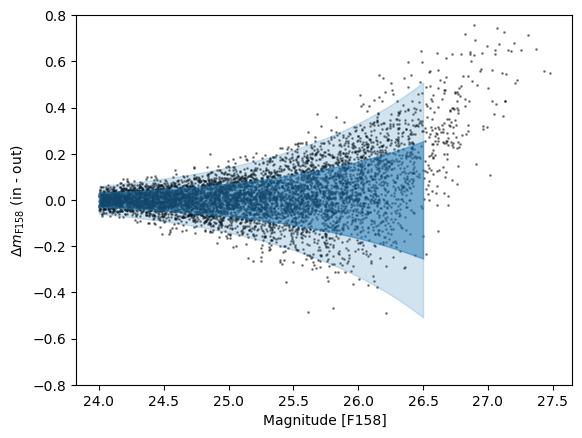

In [38]:
delta_m = tab['mag_in_F158'] - tab['mag_out_F158']
plt.scatter(tab['mag_in_F158'], delta_m, s=1, c='k', alpha=0.4)

_x = np.linspace(24, 26.5, 100)
sigma_pred = 10**(0.37 * _x - 10.4)
plt.fill_between(_x, sigma_pred, -sigma_pred, alpha=0.5, color='C0')
plt.fill_between(_x, sigma_pred * 2, -sigma_pred * 2, alpha=0.2, color='C0')

plt.ylim(-0.8, 0.8)
plt.xlabel('Magnitude [F158]')
plt.ylabel(r'$\Delta m_{\rm F158}$ (in - out)')

In [40]:
delta_m = tab["mag_in_F106"] - tab["mag_out_F106"]
mag_bins = np.arange(23.0, 27, 0.3)

scatter_tab = delta_m_scatter_vs_mag(
    tab["mag_in_F106"],
    delta_m,
    mag_bins=mag_bins,
    clip_sigma=3.0,
    clip_iters=3,
    method="mad",        # strongly recommended
    min_per_bin=20,
)
# Fit for a relation between sigma_mag and mag
flag = (scatter_tab['mag_center'] <= 26.0) & ~np.isnan(scatter_tab['scatter'])
print('Best fit in F106 :', np.polyfit(scatter_tab['mag_center'][flag], np.log10(scatter_tab['scatter'][flag]), 1))

Best fit in F106 : [  0.38426587 -10.92600549]


Text(0, 0.5, '$\\Delta m_{\\rm F106}$ (in - out)')

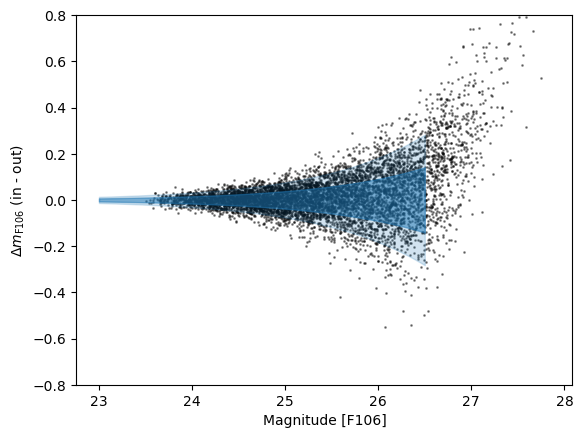

In [41]:
plt.scatter(tab['mag_in_F106'], delta_m, s=1, c='k', alpha=0.4)

_x = np.linspace(23, 26.5, 100)
sigma_pred = 10**(0.38 * _x - 10.92)
plt.fill_between(_x, sigma_pred, -sigma_pred, alpha=0.5, color='C0')
plt.fill_between(_x, sigma_pred * 2, -sigma_pred * 2, alpha=0.2, color='C0')

plt.ylim(-0.8, 0.8)
plt.xlabel('Magnitude [F106]')
plt.ylabel(r'$\Delta m_{\rm F106}$ (in - out)')

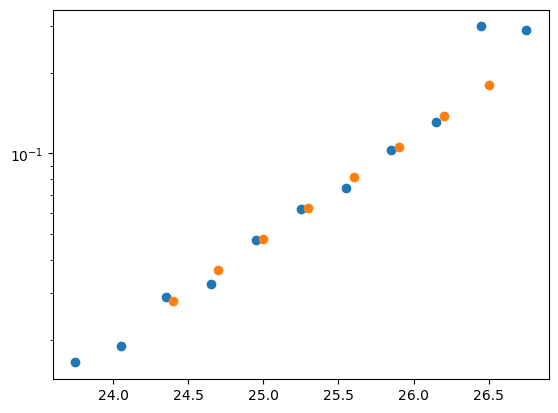

In [156]:
plt.scatter(scatter_tab['mag_center'], scatter_tab['scatter'])
plt.scatter(cens, 10**(0.384 * cens - 10.92))

plt.yscale('log')

Text(0, 0.5, 'Uncertainty (mag)')

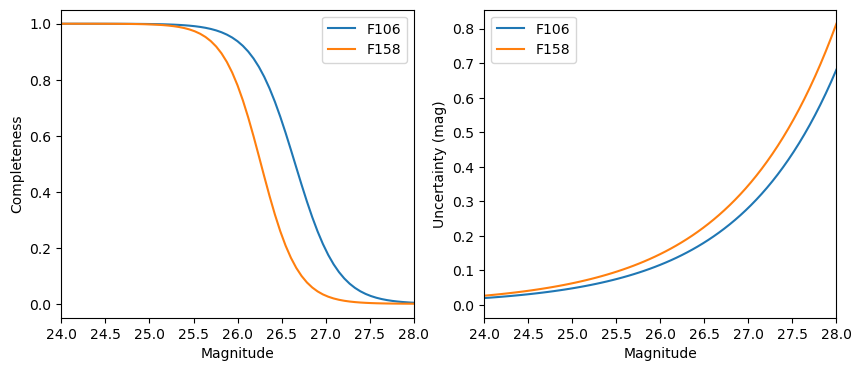

In [203]:
def logistic_completeness(m, m50, w):
    return 1.0 / (1.0 + np.exp((m - m50) / w))

def mag_uncertainty_func(m, slope, intercept):
    return 10**(m * slope + intercept)

completeness_dict = {'F158': [26.265128309473074, 0.20950393512684282], 
                     'F106': [26.65420231875137, 0.24173024529576023]} # HLWAS depth
mag_uncertainty_dict = {'F158': [0.37152117, -10.49171066], 
                        'F106': [0.38426587, -10.92600549]} # HLWAS depth

fig, [ax1, ax2] = plt.subplots(1, 2, figsize=(10, 4))

plt.sca(ax1)
mag = np.linspace(22, 28, 100)
plt.plot(mag, logistic_completeness(mag, *completeness_dict['F106']), label='F106')
plt.plot(mag, logistic_completeness(mag, *completeness_dict['F158']), label='F158')
plt.xlim(24, 28)
plt.legend()
plt.xlabel('Magnitude')
plt.ylabel('Completeness')

plt.sca(ax2)
plt.plot(mag, mag_uncertainty_func(mag, *mag_uncertainty_dict['F106']), label='F106')
plt.plot(mag, mag_uncertainty_func(mag, *mag_uncertainty_dict['F158']), label='F158')
# plt.axvline(26.5, color='C0', label='F106 limit', ls=':')
# plt.axvline(26.4, color='C1', label='F158 limit', ls=':')
plt.xlim(24, 28)
plt.legend()
plt.xlabel('Magnitude')
plt.ylabel('Uncertainty (mag)')


In [65]:
-2.5 * np.log10(np.sqrt(2))

np.float64(-0.37628749457997657)

## Pandeia

In [107]:
from pandeia.engine.perform_calculation import perform_calculation
from pandeia.engine.calc_utils import build_default_calc
 
# Get Default Parameters
calc = build_default_calc('roman', 'wfi', 'imaging')

# Update the background model to a different set
calc['background'] = 'hlwas-medium_field1'
calc['background_level'] = 'medium'


# Set the global variable for the filter name (change to any valid filter)
FILTER = 'f158'

# Set the MA table to im_135_8
calc['configuration']['detector']['ma_table_name'] = 'im_135_8'

# Modify defaults to simulate a 25th AB magnitude source
MAG = 26.4
calc['scene'][0]['spectrum']['normalization']['norm_flux'] = MAG
calc['scene'][0]['spectrum']['normalization']['norm_fluxunit'] = 'abmag'
calc['scene'][0]['spectrum']['normalization']['bandpass'] = f'wfi,imaging,{FILTER}'
calc['scene'][0]['spectrum']['normalization']['type'] = 'roman'
 
# Set number of exposures and filter
NEXP = 6
calc['configuration']['detector']['nexp'] = NEXP
calc['configuration']['instrument']['filter'] = FILTER

calc['strategy']['aperture_size'] = 0.2 # 0.2
calc['strategy']['background_subtraction'] = False

# Run calculation and return signal-to-noise ratio
report = perform_calculation(calc)
snr = report['scalar']['sn']

print(f'Estimated S/N: {snr:.2f}')

temp = report['scalar']
print(temp['extracted_flux'], temp['extracted_noise'])

Estimated S/N: 4.99
0.570562562248102 0.1143088737999052


In [ ]:
temp['']

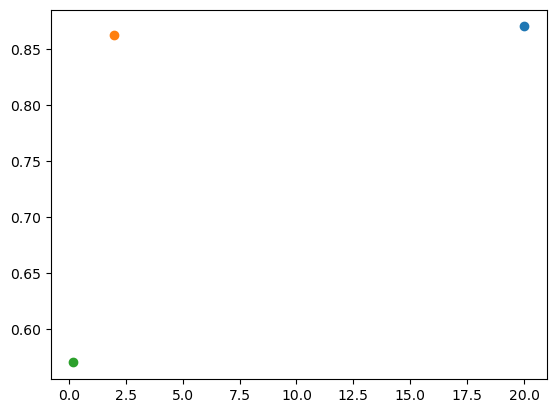

In [84]:
plt.scatter(20, 0.87)
plt.scatter(2, 0.8620935562443666)
plt.scatter(0.2, 0.570562562248102)

In [68]:
report.keys()

dict_keys(['sub_reports', 'input', '1d', '2d', '3d', 'scalar', 'information', 'transform', 'warnings', 'web_report'])

In [69]:
temp = report['scalar']

In [ ]:
F158, total flux 8.3
F106, total flux 8.26

In [ ]:
5 pix: F106 	6.94
F158 6.78

In [70]:
temp

{'total_exposure_time': 139.1487,
 'all_dithers_time': 139.1487,
 'exposure_time': 139.1487,
 'measurement_time': 135.98622,
 'saturation_time': 139.1487,
 'photon_collect': 139.1487,
 'science_time': 135.98622,
 'total_integrations': 1,
 'duty_cycle': 1.0,
 'cr_ramp_rate': 0.0034080099685425405,
 'extraction_area': np.float64(10.385430259801078),
 'background_area': None,
 'fraction_saturation': np.float64(0.0012305584622250795),
 'sat_nresultants': np.int64(8),
 'sat_nresultantsp1': np.int64(8),
 'brightest_pixel': np.float32(0.8843478),
 'filter': 'f158',
 'disperser': None,
 'detector': 'wfi01',
 'x_offset': 0.0,
 'y_offset': 0.0,
 'aperture_size': 0.2,
 'sn': np.float64(2.0377349797725173),
 'extracted_flux': np.float64(0.570562562248102),
 'extracted_noise': np.float64(0.27999841388196456),
 'background_total': np.float64(6.441571646259445),
 'background_sky': np.float64(6.441571646259445),
 'contamination': np.float64(0.0),
 'reference_wavelength': np.float64(1.5722905706884407)

In [110]:
sigma_pix = np.sqrt(temp['background_sky'] * temp['measurement_time'])

In [114]:
sigma_F = np.sqrt(temp['extraction_area']) * sigma_pix

In [116]:
F = temp['extracted_flux'] * temp['measurement_time']

In [117]:
F / sigma_F

np.float64(1.99259107294895)

In [71]:
 # * (1 + temp['extraction_area'] / temp['background_area'])

In [72]:
noise = np.sqrt((temp['background_sky'] + temp['extracted_flux']) * temp['measurement_time']) / temp['measurement_time']

temp['extracted_flux'] / noise, temp['sn']

(np.float64(2.5126130606210384), np.float64(2.0377349797725173))

In [73]:
temp['extracted_flux']

np.float64(0.570562562248102)

In [ ]:
F106 signal: 0.6739576587308646; F158 signal: 0.570562562248102

In [74]:
0.6739576587308646 / 0.570562562248102

1.1812160546870976

In [ ]:
0.12631269464884368 e- /s 